### Cycle Tracking — Data Exploration

Explores the preprocessed interday and intraday outputs from `src/dataset.py`.

In [71]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates                                                                               

from src.config import PROCESSED_DATA_DIR

#### Load processed data

In [26]:
interday = pd.read_csv(PROCESSED_DATA_DIR / "interday.csv")
intraday = pd.read_csv(PROCESSED_DATA_DIR / "intraday.csv", parse_dates=["datetime"])

print(f"Interday: {interday.shape}")
print(f"Intraday: {intraday.shape}")

Interday: (3270, 34)
Intraday: (859104, 10)


In [48]:
# Days per subject — interday vs intraday
MIN_DAYS = 30

interday_days = interday.groupby("id")["day_in_study"].nunique().rename("interday_days")
intraday_days = intraday.groupby("id")["day_in_study"].nunique().rename("intraday_days")

days_summary = pd.concat([interday_days, intraday_days], axis=1).sort_values("intraday_days")
days_summary["below_min"] = days_summary.min(axis=1) < MIN_DAYS

print(f"Subjects: {len(days_summary)}  |  Below {MIN_DAYS} days in either dataset: {days_summary['below_min'].sum()}")

Subjects: 38  |  Below 30 days in either dataset: 0


#### Interday overview

In [55]:
print(interday.info())
print(interday.head())

<class 'pandas.DataFrame'>
RangeIndex: 3270 entries, 0 to 3269
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3270 non-null   int64  
 1   day_in_study          3270 non-null   int64  
 2   is_weekend            3270 non-null   bool   
 3   phase                 3269 non-null   str    
 4   lh                    3154 non-null   float64
 5   estrogen              3153 non-null   float64
 6   flow_volume           2906 non-null   str    
 7   flow_color            2906 non-null   str    
 8   appetite              3027 non-null   str    
 9   exerciselevel         3027 non-null   str    
 10  headaches             3027 non-null   str    
 11  cramps                3027 non-null   str    
 12  sorebreasts           3027 non-null   str    
 13  fatigue               3027 non-null   str    
 14  sleepissue            3027 non-null   str    
 15  moodswing             3027 non-n

In [58]:
# Interday missingness (%) — key columns
interday_miss_cols = ["lh", "estrogen", "sleep_min_total", "nightly_temperature", "heart_rate_var_mean"]

interday_miss = interday[interday_miss_cols].apply(lambda g: g.isna().mean() * 100).round(1)

print("Interday missingness total (%)")
print(interday_miss)

interday_miss_subject = (
    interday.groupby("id")[interday_miss_cols]
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
)
print("Interday missingness per subject (%)")
print(interday_miss_subject)

Interday missingness total (%)
lh                      3.5
estrogen                3.6
sleep_min_total        13.5
nightly_temperature    17.4
heart_rate_var_mean    18.3
dtype: float64
Interday missingness per subject (%)
      lh  estrogen  sleep_min_total  nightly_temperature  heart_rate_var_mean
id                                                                           
2    0.0       0.0             25.6                 25.6                  6.7
3   10.0      10.0             13.3                 16.7                100.0
4   13.3      13.3             25.3                 26.5                 19.3
6   10.1      10.1             20.2                 33.7                 33.7
7    0.0       0.0             14.4                 15.6                  6.7
8    5.8       5.8             30.8                 30.8                 13.5
9    1.1       1.1             14.4                 15.6                  0.0
10   0.0       0.0              3.3                  4.4                 82

##### Example hormone cycle

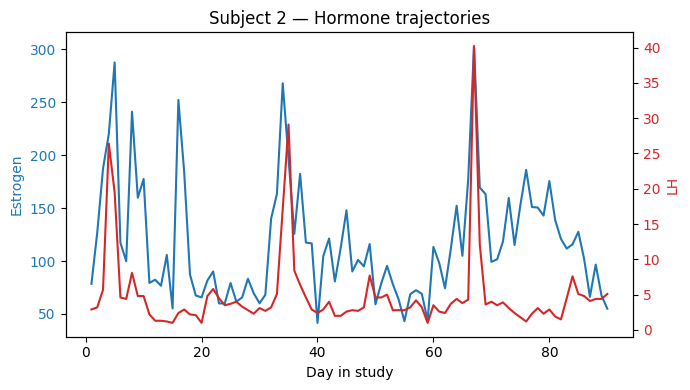

In [43]:
# Hormone trajectories for one subject
sid = interday["id"].iloc[0]  # swap for any subject id                                                         
grp = interday[interday["id"] == sid].sort_values("day_in_study")                                               
                                                                                                                  
fig, ax1 = plt.subplots(figsize=(7, 4))                                                                                       
ax2 = ax1.twinx()                                                                                               
                                                                                                                
ax1.plot(grp["day_in_study"], grp["estrogen"], color="tab:blue")
ax2.plot(grp["day_in_study"], grp["lh"], color="tab:red")

ax1.set_title(f"Subject {sid} — Hormone trajectories")
ax1.set_xlabel("Day in study")
ax1.set_ylabel("Estrogen", color="tab:blue")                                                                    
ax2.set_ylabel("LH", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")                                                              
plt.tight_layout()
plt.show() 

#### Intraday overview

In [59]:
intraday.info()
print(intraday.head())

<class 'pandas.DataFrame'>
RangeIndex: 859104 entries, 0 to 859103
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   id             859104 non-null  int64         
 1   day_in_study   859104 non-null  int64         
 2   is_weekend     859104 non-null  bool          
 3   datetime       859104 non-null  datetime64[us]
 4   time           859104 non-null  str           
 5   bpm            854754 non-null  float64       
 6   glucose_value  743509 non-null  float64       
 7   azm_cardio     859104 non-null  float64       
 8   azm_fat_burn   859104 non-null  float64       
 9   azm_peak       859104 non-null  float64       
dtypes: bool(1), datetime64[us](1), float64(5), int64(2), str(1)
memory usage: 59.8 MB
   id  day_in_study  is_weekend            datetime   time  bpm  \
0   2             1        True 2022-01-01 00:00:00  00:00  NaN   
1   2             1        True 2022-01-01 00:05:00  00

In [61]:
# Intraday missingness per subject (%) — bpm and glucose (post-interpolation)
intraday_miss_cols = ["bpm", "glucose_value"]

intraday_miss = intraday[intraday_miss_cols].apply(lambda g: g.isna().mean() * 100).round(1)

print("Intraday missingness total (%)")
print(intraday_miss)

intraday_miss_subject = (
    intraday.groupby("id")[intraday_miss_cols]
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
)
print("Intraday missingness per subject (%)")
print(intraday_miss_subject)

Intraday missingness total (%)
bpm               0.5
glucose_value    13.5
dtype: float64
Intraday missingness per subject (%)
    bpm  glucose_value
id                    
2   0.6            5.2
3   0.6           30.3
4   0.7           20.8
6   0.5           41.1
7   0.0           11.4
8   0.2            1.1
9   0.6            0.8
10  0.7            2.7
11  0.3            6.2
12  0.2            2.9
13  0.2            3.4
14  0.9           41.2
15  0.2            0.9
16  0.5            8.8
18  0.1            3.9
19  0.1            1.3
20  0.3            6.8
22  0.7            5.2
23  0.7           40.8
24  0.7            0.6
26  0.1            2.5
27  0.2           34.9
32  0.6           52.9
33  0.5            5.3
34  0.4           10.0
37  0.5            6.9
38  0.3           11.6
39  0.5            0.2
40  1.8           26.5
41  0.1            3.1
42  0.2            0.7
43  3.3            3.4
44  0.4           42.9
45  0.8            5.9
46  0.3           94.2
47  0.0            1.1

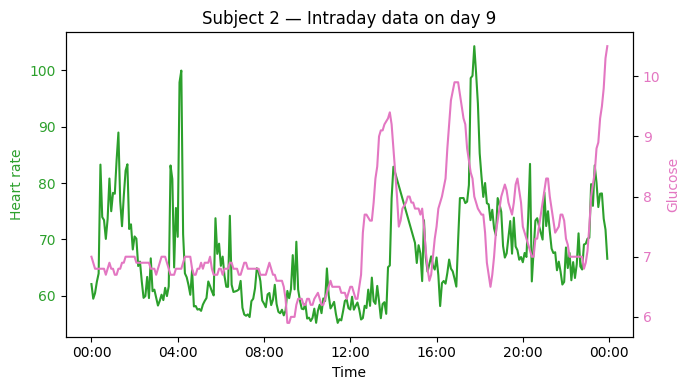

In [ ]:
# One subject, one day — bpm trace
sid = intraday["id"].iloc[0]
day = 10
grp = intraday[(intraday["id"] == sid) & (intraday["day_in_study"] == day)]

fig, ax1 = plt.subplots(figsize=(7, 4))                                                                                       
ax2 = ax1.twinx()                                                                                               
                                                                                                                
ax1.plot(grp["datetime"], grp["bpm"], color="tab:green")
ax2.plot(grp["datetime"], grp["glucose_value"], color="tab:pink")

ax1.set_title(f"Subject {sid} — Intraday data on day {day}")
ax1.set_xlabel("Time")
ax1.set_ylabel("Heart rate", color="tab:green")                                                                    
ax2.set_ylabel("Glucose", color="tab:pink")
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=4))   # tick every 4h                                    
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax1.tick_params(axis="y", labelcolor="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:pink")                                                              
plt.tight_layout()
plt.show() 